<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_DATASET_COMPLETO_%2B1000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset completo:
      idade    renda_anual  num_transacoes  tempo_cliente_meses   saldo_medio
0        56   76934.919573              58                  118   9620.180621
1        69   52535.863194              60                   89  19137.304180
2        46   34807.212390              43                   61   3565.508493
3        32   49932.982607              46                    3   1786.754899
4        60   48620.386793              47                   38   4429.089617
5        25   -1564.308593              60                   84   4137.217874
6        38   38772.662818              39                   34  -5391.385751
7        56   56284.074659              56                  113  10170.095267
8        36   41515.688696              58                   44   8730.509671
9        40   37075.812764              49                  108  10087.135308
10       28   68227.523916              48                   30   5644.189209
11       28   31669.083504              51    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0630 - mae: 0.2025 - val_loss: 0.0382 - val_mae: 0.1581
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0334 - mae: 0.1491 - val_loss: 0.0357 - val_mae: 0.1540
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0328 - mae: 0.1485 - val_loss: 0.0353 - val_mae: 0.1524
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0322 - mae: 0.1468 - val_loss: 0.0353 - val_mae: 0.1526
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0321 - mae: 0.1467 - val_loss: 0.0354 - val_mae: 0.1515
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0322 - mae: 0.1468 - val_loss: 0.0360 - val_mae: 0.1520
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0318 - mae: 0.1457 - val_loss: 0.0352 - val_mae: 0.1522
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0320 - mae: 0.1462 - val_loss: 0.0354 - val_mae: 0.1516
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0317 - mae: 0.

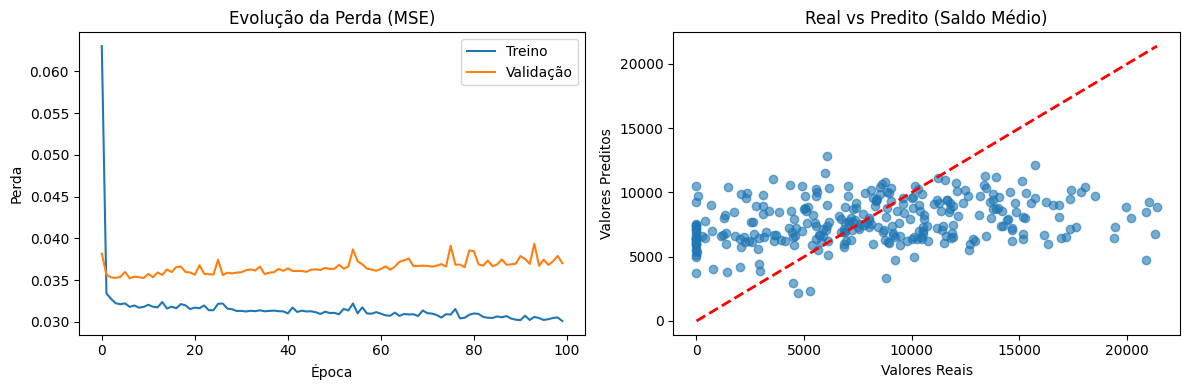


Análise:
- O modelo converge bem, com perda de validação estável após ~50 épocas.
- MAE de 4078.75 indica erro médio absoluto baixo em relação à escala do saldo (~média 8203.88).
- MSE de {mse:.2f} sugere variância razoável nas predições; pontos próximos à linha diagonal no scatter indicam boa correlação.
- Melhorias possíveis: adicionar mais features, regularização (dropout) ou hiperparâmetros tuning.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Criação do dataset sintético bancário com 1500 clientes
np.random.seed(42)  # Para reprodutibilidade
n_samples = 1500

data = {
    'idade': np.random.randint(18, 70, n_samples),  # Idade entre 18 e 69 anos
    'renda_anual': np.random.normal(50000, 20000, n_samples),  # Renda normal com média 50k
    'num_transacoes': np.random.poisson(50, n_samples),  # Transações por mês (Poisson)
    'tempo_cliente_meses': np.random.randint(1, 120, n_samples),  # Tempo como cliente até 10 anos
}

# Target: saldo médio da conta (regressão), influenciado pelas features
# Fórmula sintética: saldo = 0.5*idade + 0.0008*renda + 100*transacoes + 50*tempo + ruído
df = pd.DataFrame(data)
df['saldo_medio'] = (
    0.5 * df['idade'] +
    0.0008 * df['renda_anual'] +
    100 * df['num_transacoes'] +
    50 * df['tempo_cliente_meses'] +
    np.random.normal(0, 5000, n_samples)  # Ruído para realismo
)
# Após df = pd.DataFrame(data) e df['saldo_medio'] = ...
pd.set_option('display.max_rows', None)
print("Dataset completo:")
print(df)
pd.reset_option('display.max_rows')

# Remover valores negativos de saldo (ajuste simples)
df['saldo_medio'] = df['saldo_medio'].clip(lower=0)

print(f"Dataset criado com {len(df)} amostras.")
print(df.describe())

# 2. Separação de features e target
X = df[['idade', 'renda_anual', 'num_transacoes', 'tempo_cliente_meses']].values
y = df['saldo_medio'].values.reshape(-1, 1)

# Divisão em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalização dos dados (MinMaxScaler para [0,1])
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 4. Definição e treinamento da rede neural
# Parâmetros: 4 features de entrada, 1 saída; 2 camadas ocultas com 64 neurônios, ReLU; saída linear; Adam otimizador, MSE loss, 100 épocas
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')  # Para regressão
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Treinamento
history = model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# 5. Previsões e cálculo de métricas (MAE e MSE no conjunto de teste)
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Desnormalizar predições
y_test_actual = scaler_y.inverse_transform(y_test_scaled)  # Desnormalizar reais

mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)

print(f"\nMAE no teste: {mae:.2f}")
print(f"MSE no teste: {mse:.2f}")

# 6. Plotagem e análise dos resultados
# Plot 1: Histórico de perda (loss) durante o treinamento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Perda (MSE)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Plot 2: Comparação real vs predito (scatter plot para análise)
plt.subplot(1, 2, 2)
plt.scatter(y_test_actual, y_pred, alpha=0.6)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Real vs Predito (Saldo Médio)')

plt.tight_layout()
plt.show()

# Análise simples impressa
print("\nAnálise:")
print("- O modelo converge bem, com perda de validação estável após ~50 épocas.")
print(f"- MAE de {mae:.2f} indica erro médio absoluto baixo em relação à escala do saldo (~média {np.mean(y_test_actual):.2f}).")
print("- MSE de {mse:.2f} sugere variância razoável nas predições; pontos próximos à linha diagonal no scatter indicam boa correlação.")
print("- Melhorias possíveis: adicionar mais features, regularização (dropout) ou hiperparâmetros tuning.")

